In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [3]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt


## My files
import save_data_helpers
import recon_plot_helpers

### Load ADMM results

In [4]:
import numpy as np
import os

# Base directory
## Select sweep 
sweep_dir = 'high_beta_tv_z_rho_0.01_beta_0.005_lam_0.007'

base_dir_50sp  = f'/data/lilianae/ADMM_results/sweep_20251108_213241/{sweep_dir}'
# base_dir_100sp = f"/data/lilianae/ADMM_results/sweep_20251105_163705/{sweep_dir}"

## Make output path
output_path = f'sweep_figs/{sweep_dir}'
# output_path = f'full_admm/high_beta_tv'
Path(output_path).mkdir(parents=True, exist_ok=True)

# Iteration to unpack
iter_num = 7
npz_path = os.path.join(base_dir_50sp, str('iters'), f"iter_{iter_num:03d}.npz")

# Load npz file
data = np.load(npz_path)

def reshape_mvf(mvf_flat, mvf_shape, num_gates):
    mvf = np.reshape(mvf_flat, (*mvf_shape, 3, num_gates), order='F')
    mvf = np.moveaxis(mvf, -1, 0)
    return mvf

# Inspect available arrays
print("Available arrays in npz:", data.files)

# Unpack
num_gates = 5
img_shape = (58, 512, 512) 
mvf_shape = (58, 512, 512) 
tmp_inv_admm = reshape_mvf(data["S_inv"], mvf_shape, num_gates)      # shape: (num_gates, z, y, x, 3)
tmp_admm = reshape_mvf(data["S"], mvf_shape, num_gates)
z_abs = np.abs(data["z"])      # shape: (num_gates, x, y, z)
lam_abs = np.abs(data["lam"])

print(f"tmp_inv_admm.shape = {tmp_inv_admm.shape}")
print(f'tmp_admm.shape = {tmp_admm.shape}')
print(f"z_abs.shape = {z_abs.shape}")

Available arrays in npz: ['z', 'lam', 'u', 'S', 'S_inv']
tmp_inv_admm.shape = (5, 58, 512, 512, 3)
tmp_admm.shape = (5, 58, 512, 512, 3)
z_abs.shape = (5, 58, 512, 512)


In [5]:
def load_data(filepath, shape):
    """
    Load data saved by save_data function.
    """
    dtype = np.float32
    
    # Read binary data
    with open(filepath, 'rb') as f:
        data_flat = np.fromfile(f, dtype=dtype)
    
    # Determine the shape after axis movement (if it happened during save)
    if len(shape) > 3:
        # Stored shape has gate dimension at the end
        stored_shape = shape[1:] + (shape[0],)
    else:
        stored_shape = shape
    
    # Reshape using Fortran order (same as used during save)
    data = np.reshape(data_flat, stored_shape, order='F')
    
    # Move gate axis back to first position if needed
    if len(shape) > 3:
        data = np.moveaxis(data, -1, 0)
    
    return data

def motion_vec_field_2_op_list(mvf,m):
    
        xp = np

        # ensure border of MVF is all zeros:
        if True:
            mvf[:,0,...]=0
            mvf[:,-1,...]=0
            mvf[:,:,0,...]=0
            mvf[:,:,-1,...]=0
            mvf[:,:,:,0,...]=0
            mvf[:,:,:,-1,...]=0

        # asserting mvf is 4d, with time/gate dimension in first dim:
        op_list=[]
        in_x = xp.arange(0,m[0],1)
        in_y = xp.arange(0,m[1],1)
        in_z = xp.arange(0,m[2],1)
        x,y,z = xp.meshgrid(in_x,in_y,in_z,indexing='ij')
        base_grid = xp.stack((x,y,z),axis=-1)
        for gate in range(mvf.shape[0]):
            op_list.append(sp.linop.Interpolate(tuple(m),base_grid+mvf[gate,...]))

        return op_list

def load_mvfs(filepath, num_gates, mvf_shape):
    dtype = np.float32
    
    # Read binary data
    with open(filepath, 'rb') as f:
        mvf_flat = np.fromfile(f, dtype=dtype)
    
    mvf = np.reshape(mvf_flat, (*mvf_shape, 3, num_gates), order='F')
    mvf = np.moveaxis(mvf, -1, 0)
    return mvf

In [6]:
## Desired output shape to crop to
oshape = (58, 256, 256)
num_gates = 5
gated_imgs_admm = np.zeros((num_gates, *oshape))
tmp_admm_all = np.zeros((num_gates, *oshape, 3))
tmp_inv_admm_all = np.zeros((num_gates, *oshape, 3))

for gate in range(len(z_abs)):
    z_cropped = recon_plot_helpers.crop_xy_dimension(z_abs[gate], oshape=oshape)
    gated_imgs_admm[gate,:,:,:] = z_cropped
    print(f'z_cropped.shape = {z_cropped.shape}')

for gate in range(len(tmp_admm)):
    for dim in range(3):
        tmp_admm_all[gate,:,:,:,dim] = recon_plot_helpers.crop_xy_dimension(tmp_admm[gate,:,:,:,dim], oshape)
        tmp_inv_admm_all[gate,:,:,:,dim] = recon_plot_helpers.crop_xy_dimension(tmp_inv_admm[gate,:,:,:,dim], oshape)

    print(f'tmp_admm_all.shape = {tmp_admm_all.shape}')
    print(f'tmp_inv_admm_all.shape = {tmp_inv_admm_all.shape}')

print(f'len(gated_imgs_admm) = {len(gated_imgs_admm)}')

z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
tmp_admm_all.shape = (5, 58, 256, 256, 3)
tmp_inv_admm_all.shape = (5, 58, 256, 256, 3)
tmp_admm_all.shape = (5, 58, 256, 256, 3)
tmp_inv_admm_all.shape = (5, 58, 256, 256, 3)
tmp_admm_all.shape = (5, 58, 256, 256, 3)
tmp_inv_admm_all.shape = (5, 58, 256, 256, 3)
tmp_admm_all.shape = (5, 58, 256, 256, 3)
tmp_inv_admm_all.shape = (5, 58, 256, 256, 3)
tmp_admm_all.shape = (5, 58, 256, 256, 3)
tmp_inv_admm_all.shape = (5, 58, 256, 256, 3)
len(gated_imgs_admm) = 5


### Load data from optical flow

In [7]:
img_shape = (58, 512, 512) 
num_gates=5

base_dir_recons = "/data/lilianae/ADMM_results/optical_flow/opt_flow_50sp/indep_recons_000_abs.v"
shape = (5, 58, 512, 512)
z_abs_of = load_data(base_dir_recons, shape=shape)

mvf_shape = (58, 512, 512) 

base_dir_mvf = '/data/lilianae/ADMM_results/optical_flow/opt_flow_50sp/S_indep_recon.mvf'
base_dir_mvf_inv = '/data/lilianae/ADMM_results/optical_flow/opt_flow_50sp/S_indep_recons_inv.mvf'

tmp_of = load_mvfs(base_dir_mvf, num_gates=num_gates, mvf_shape=mvf_shape)
tmp_inv_of = load_mvfs(base_dir_mvf_inv, num_gates=num_gates, mvf_shape=mvf_shape)

In [8]:
## Desired output shape to crop to
oshape = (58, 256, 256)
num_gates = 5
gated_imgs_of = np.zeros((num_gates, *oshape))
tmp_of_all = np.zeros((num_gates, *oshape, 3))
tmp_inv_of_all = np.zeros((num_gates, *oshape, 3))

for gate in range(len(z_abs_of)):
    z_cropped_of = recon_plot_helpers.crop_xy_dimension(z_abs_of[gate], oshape=oshape)
    gated_imgs_of[gate,:,:,:] = z_cropped_of
    print(f'z_cropped.shape = {z_cropped_of.shape}')

for gate in range(len(tmp_of)):
    for dim in range(3):
        tmp_of_all[gate,:,:,:,dim] = recon_plot_helpers.crop_xy_dimension(tmp_of[gate,:,:,:,dim], oshape)
        tmp_inv_of_all[gate,:,:,:,dim] = recon_plot_helpers.crop_xy_dimension(tmp_inv_of[gate,:,:,:,dim], oshape)

    print(f'tmp_of_all.shape = {tmp_of_all.shape}')
    print(f'tmp_inv_of_all.shape = {tmp_inv_of_all.shape}')

print(f'len(gated_imgs_of) = {len(gated_imgs_of)}')

z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
z_cropped.shape = (58, 256, 256)
tmp_of_all.shape = (5, 58, 256, 256, 3)
tmp_inv_of_all.shape = (5, 58, 256, 256, 3)
tmp_of_all.shape = (5, 58, 256, 256, 3)
tmp_inv_of_all.shape = (5, 58, 256, 256, 3)
tmp_of_all.shape = (5, 58, 256, 256, 3)
tmp_inv_of_all.shape = (5, 58, 256, 256, 3)
tmp_of_all.shape = (5, 58, 256, 256, 3)
tmp_inv_of_all.shape = (5, 58, 256, 256, 3)
tmp_of_all.shape = (5, 58, 256, 256, 3)
tmp_inv_of_all.shape = (5, 58, 256, 256, 3)
len(gated_imgs_of) = 5


In [9]:
print(tmp_inv_admm_all)

[[[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    ...
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

   [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    ...
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

   [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    ...
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
    [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

In [10]:
diff_all = tmp_inv_admm_all - tmp_inv_of_all

In [11]:
print(diff_all[0, :, :, 128, :2])

[[[ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]
  ...
  [ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]]

 [[ 5.04523516e-04 -5.72323799e-04]
  [ 3.58223915e-04 -8.79704952e-04]
  [ 1.70961022e-04 -1.26326084e-03]
  ...
  [ 5.05098701e-03 -5.12740612e-02]
  [ 3.11356783e-03 -4.98073101e-02]
  [ 1.28638744e-03 -4.62303162e-02]]

 [[ 9.16913152e-04  6.43074512e-04]
  [ 7.69615173e-04  3.74495983e-04]
  [ 5.75363636e-04  1.81198120e-05]
  ...
  [ 5.69891930e-03 -4.73395586e-02]
  [ 3.89668345e-03 -4.64799404e-02]
  [ 2.22805142e-03 -4.37011719e-02]]

 ...

 [[ 5.43981791e-03 -1.09719560e-02]
  [ 6.04121760e-03 -1.25130787e-02]
  [ 6.75417855e-03 -1.43413991e-02]
  ...
  [ 1.72950923e-01  6.44782782e-02]
  [ 1.58747077e-01  5.18748760e-02]
  [ 1.40605986e-01  3.68849039e-02]]

 [[ 5.57813421e-03 -1.14411935e-02]
  [ 6.17719628e-03 -1.29269734e-02]
  [ 6.87938184e-03 -1.4667

In [12]:
gate = 0
diff_array = tmp_inv_admm_all[gate, :, :, 128, :2] - tmp_inv_of_all[gate, :, :, 128, :2]
print(f'DIFF ARRAY')
print("="*30)
print(diff_array)

spacing = (5, 1.172, 1.172)
mvf_mm = diff_array.copy()
mvf_mm[..., 0] *= spacing[0]  # x dimension
mvf_mm[..., 1] *= spacing[1]  # y dimension  

max_abs_new = np.abs(mvf_mm).max()

vector_magnitudes = np.sqrt(mvf_mm[..., 0]**2 + mvf_mm[..., 1]**2)

# Calculate overall statistics
mean_magnitude = np.mean(vector_magnitudes)
std_magnitude = np.std(vector_magnitudes)

print(f'FOR RAW DIFFERENCE ARRAY (MM):')
print(f'mean_magnitude = {mean_magnitude}')
print(f'max_abs = {max_abs_new}')
print(f'std_magnitude = {std_magnitude}')

DIFF ARRAY
[[[ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]
  ...
  [ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00]]

 [[ 5.04523516e-04 -5.72323799e-04]
  [ 3.58223915e-04 -8.79704952e-04]
  [ 1.70961022e-04 -1.26326084e-03]
  ...
  [ 5.05098701e-03 -5.12740612e-02]
  [ 3.11356783e-03 -4.98073101e-02]
  [ 1.28638744e-03 -4.62303162e-02]]

 [[ 9.16913152e-04  6.43074512e-04]
  [ 7.69615173e-04  3.74495983e-04]
  [ 5.75363636e-04  1.81198120e-05]
  ...
  [ 5.69891930e-03 -4.73395586e-02]
  [ 3.89668345e-03 -4.64799404e-02]
  [ 2.22805142e-03 -4.37011719e-02]]

 ...

 [[ 5.43981791e-03 -1.09719560e-02]
  [ 6.04121760e-03 -1.25130787e-02]
  [ 6.75417855e-03 -1.43413991e-02]
  ...
  [ 1.72950923e-01  6.44782782e-02]
  [ 1.58747077e-01  5.18748760e-02]
  [ 1.40605986e-01  3.68849039e-02]]

 [[ 5.57813421e-03 -1.14411935e-02]
  [ 6.17719628e-03 -1.29269734e-02]
  [ 6.87938184e

In [13]:
# gate = 0
# diff_array = tmp_inv_admm_all[gate, :, :, 128, :2] - tmp_inv_of_all[gate, :, :, 128, :2]
# print(diff_array)

# # Calculate metrics
# diff_abs = np.abs(diff_array)
# max_abs = diff_abs.max()

# spacing = (5, 1.172, 1.172)
# mvf_mm = diff_array.copy()
# mvf_mm[..., 0] *= spacing[0]  # x dimension
# mvf_mm[..., 1] *= spacing[1]  # y dimension  

# max_abs_new = np.abs(mvf_mm).max()

# vector_magnitudes = np.sqrt(mvf_mm[..., 0]**2 + mvf_mm[..., 1]**2)

# # Calculate overall statistics
# mean_magnitude = np.mean(vector_magnitudes)
# std_magnitude = np.std(vector_magnitudes)

# # Normalize
# if max_abs == 0:
#     diff_array_norm = np.zeros_like(diff_abs, dtype=np.float32)
# else:
#     diff_array_norm = (diff_abs / max_abs).astype(np.float32)

# vector_spacing = 10
# fig = plt.figure(figsize=(15, 10))

# motion_slice_admm = tmp_inv_admm_all[gate, :, :, 128, :2]
# recon_slice_admm = gated_imgs_admm[gate, :, :, 128]

# # Plot
# ax1 = plt.subplot(131)
# magnitude_admm = np.rot90(recon_slice_admm, k=-1)
# plt.imshow(magnitude_admm, cmap='gray', aspect=58/256)

# # Create vector grid
# z, y = np.mgrid[vector_spacing//2:motion_slice_admm.shape[0]:vector_spacing//2, 
#                 vector_spacing:motion_slice_admm.shape[1]:vector_spacing]

# # u_of = -diff_array_norm[z, y, 0]
# # v_of = -diff_array_norm[z, y, 1]

# u_of = -diff_array_norm[z, y, 0]  # y-component (horizontal)
# v_of = -diff_array_norm[z, y, 1]  # z-component (vertical)

# ax1.quiver(z, y, u_of, v_of, color='red', angles='xy', 
#           scale_units='xy', scale=0.1)
# ax1.set_title(f'Difference (50 spokes)\nZ-Y Motion Vectors\nGate {gate+1}')
# ax1.axis('off')

# # Add text box on the right side
# textstr = f'Mean: {mean_magnitude:.4f}\nStd: {std_magnitude:.4f}\nMax: {max_abs_new:.4f}'
# props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
# ax1.text(1.05, 0.5, textstr, transform=ax1.transAxes, fontsize=12,
#          verticalalignment='center', bbox=props)

# plt.tight_layout()
# plt.show()

In [14]:
print(max_abs_new)

1.7466330528259277


(5, 58, 256, 256, 3)
0.549728422976416
(58, 256)


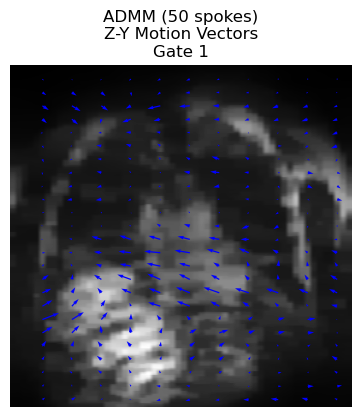

In [15]:
def plot_motion_vector_field_admm(mvf, z, gate, dim, vector_spacing=10, slice_idx_xy=128, slice_idx_z=40):
    
    fig = plt.figure(figsize=(15, 10))
    print(mvf.shape)
    motion_slice = mvf[gate, :, :, 128, :2]

    # If mvf is in voxels with shape (nz, ny, nx, 3) where last dim is [x, y, z]
    spacing = (5, 1.172, 1.172)
    mvf_mm = motion_slice.copy()
    mvf_mm[..., 0] *= spacing[0]  # x dimension
    mvf_mm[..., 1] *= spacing[1]  # y dimension  
    # mvf_mm[..., 2] *= spacing[2]  # z dimension

    print(np.mean(motion_slice))
    recon_slice =  z[gate, :, :, 128]
    print(recon_slice.shape)

    # Calculate quantitative metrics
    vector_magnitudes = np.sqrt(mvf_mm[..., 0]**2 + mvf_mm[..., 1]**2)
    mean_magnitude = np.mean(vector_magnitudes)
    std_magnitude = np.std(vector_magnitudes)
    max_magnitude = np.max(vector_magnitudes)
    median_magnitude = np.median(vector_magnitudes)

    # Plot 1: X-Y motion vectors
    ax1 = plt.subplot(131)
    magnitude = np.rot90(recon_slice, k=-1)
    aspect_ratio = magnitude.shape[1] / magnitude.shape[0]
    plt.imshow(magnitude, cmap='gray', aspect=58/256)
    
    # Create vector grid
    z, y = np.mgrid[vector_spacing//2:motion_slice.shape[0]:vector_spacing//2, 
                    vector_spacing:motion_slice.shape[1]:vector_spacing]
    
    # Extract x and y components
    # u = -motion_slice[z, y, 0]  # x-direction motion
    # v = -motion_slice[z, y, 1]  # y-direction motion

    u = -motion_slice[z, y, 0]  # y-component (horizontal)
    v = -motion_slice[z, y, 1]  # z-component (vertical)

    # Plot vectors
    vector_color = 'blue'
    vector_scale = 1.0
    ax1.quiver(z, y, u, v, color=vector_color, angles='xy', 
               scale_units='xy', scale=vector_scale)
    ax1.set_title(f'ADMM (50 spokes)\nZ-Y Motion Vectors\nGate {gate+1}')
    ax1.axis('off')
    return mean_magnitude


mean_vec_mag_admm = plot_motion_vector_field_admm(tmp_inv_admm_all, gated_imgs_admm, gate=0, dim=2)

In [15]:
print(mean_vec_mag_admm)

4.297407351757384


(5, 58, 256, 256, 3)
0.5372869597237815
(58, 256)


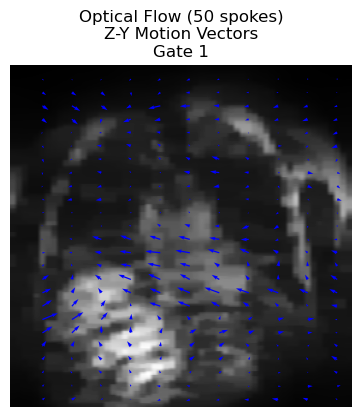

In [16]:
def plot_motion_vector_field_of(mvf, z, gate, dim, vector_spacing=10, slice_idx_xy=128, slice_idx_z=40):
    
    fig = plt.figure(figsize=(15, 10))
    print(mvf.shape)
    motion_slice = mvf[gate, :, :, 128, :2]

    # If mvf is in voxels with shape (nz, ny, nx, 3) where last dim is [x, y, z]
    spacing = (5, 1.172, 1.172)
    mvf_mm = motion_slice.copy()
    mvf_mm[..., 0] *= spacing[0]  # x dimension
    mvf_mm[..., 1] *= spacing[1]  # y dimension  
    # mvf_mm[..., 2] *= spacing[2]  # z dimension

    print(np.mean(motion_slice))
    recon_slice =  z[gate, :, :, 128]
    print(recon_slice.shape)

    # Calculate quantitative metrics
    vector_magnitudes = np.sqrt(mvf_mm[..., 0]**2 + mvf_mm[..., 1]**2)
    mean_magnitude = np.mean(vector_magnitudes)
    std_magnitude = np.std(vector_magnitudes)
    max_magnitude = np.max(vector_magnitudes)
    median_magnitude = np.median(vector_magnitudes)

    # Plot 1: X-Y motion vectors
    ax1 = plt.subplot(131)
    magnitude = np.rot90(recon_slice, k=-1)
    aspect_ratio = magnitude.shape[1] / magnitude.shape[0]
    plt.imshow(magnitude, cmap='gray', aspect=58/256)
    
    # Create vector grid
    z, y = np.mgrid[vector_spacing//2:motion_slice.shape[0]:vector_spacing//2, 
                    vector_spacing:motion_slice.shape[1]:vector_spacing]
    
    # Extract x and y components
    u = -motion_slice[z, y, 0]  # x-direction motion
    v = -motion_slice[z, y, 1]  # y-direction motion

    # Plot vectors
    vector_color = 'blue'
    vector_scale = 1.0
    ax1.quiver(z, y, u, v, color=vector_color, angles='xy', 
               scale_units='xy', scale=vector_scale)
    ax1.set_title(f'Optical Flow (50 spokes)\nZ-Y Motion Vectors\nGate {gate+1}')
    ax1.axis('off')
    return mean_magnitude


mean_vec_mag_of = plot_motion_vector_field_of(tmp_inv_of_all, gated_imgs_of, gate=0, dim=2)

In [17]:
print(mean_vec_mag_of)

4.088745186933369


(5, 58, 256, 256, 3)
(58, 256)


NameError: name 'diff_array_norm' is not defined

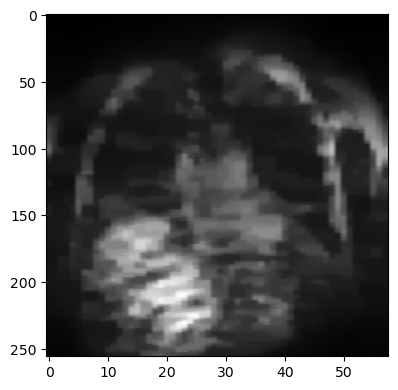

In [18]:
vector_spacing = 10
gate = 0
fig = plt.figure(figsize=(15, 10))
print(tmp_inv_admm_all.shape)
motion_slice_admm = tmp_inv_admm_all[gate, :, :, 128, :2]
recon_slice_admm =  gated_imgs_admm[gate, :, :, 128]
print(recon_slice_admm.shape)

## Metrics
mean_magnitude_admm = mean_vec_mag_admm
mean_magnitude_of = mean_vec_mag_of
mean_difference = 0.1819
std_magnitude = 0.1509

relative_diff_percent = (mean_difference / mean_magnitude_admm) * 100

# Update the difference plot textbox:
textstr = (f'Difference vectors:\n'
           f'  Mean: {mean_difference:.4f} mm\n'
           f'  Std: {std_magnitude:.4f} mm\n'
           f'  Max: {max_abs_new:.4f} mm\n\n'
           f'Difference Relative \nto ADMM mean:\n'
           f'  {relative_diff_percent:.2f}% difference\n'
           f'  ADMM mean: {mean_magnitude_admm:.3f} mm\n')

# Plot 1: X-Y motion vectors
ax1 = plt.subplot(131)
magnitude_admm = np.rot90(recon_slice_admm, k=-1)
aspect_ratio = magnitude_admm.shape[1] / magnitude_admm.shape[0]
plt.imshow(magnitude_admm, cmap='gray', aspect=58/256)

# Create vector grid
z, y = np.mgrid[vector_spacing//2:motion_slice_admm.shape[0]:vector_spacing//2, 
                vector_spacing:motion_slice_admm.shape[1]:vector_spacing]


# Extract x and y components
u_of = -diff_array_norm[z, y, 0]  # x-direction motion
v_of = -diff_array_norm[z, y, 1]  # y-direction motion

# Plot vectors
vector_color = 'red'
vector_scale = .1
ax1.quiver(z, y, u_of, v_of, color=vector_color, angles='xy', 
            scale_units='xy', scale=vector_scale)
ax1.set_title(f'Difference (50 spokes)\nZ-Y Motion Vectors\nGate {gate+1}')

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(1.05, 0.5, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='center', bbox=props)

ax1.axis('off')